# Correlation Analysis

Phân tích mối tương quan giữa các biến số trong dataset YouTube videos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

In [2]:
# Load cleaned data (sau outlier removal)
df = pd.read_csv('data/youtube_no_outliers_clean.csv')

numerical_cols = ['duration', 'bitrate', 'bitrate(video)', 'height', 'width',
                  'frame rate', 'frame rate(est.)', 'views', 'likes', 'comments']
df[numerical_cols].head()

,duration,bitrate,bitrate(video),height,width,frame rate,frame rate(est.),views,likes,comments
0,562,431.0,300.0,320,240,29.97,0.00,43,1,0
1,300,3087.0,2929.0,1280,720,23.98,23.98,222,2,0
2,43,634.0,501.0,480,360,29.97,29.97,138,0,0
3,228,5880.0,5686.0,1920,1080,25.00,25.00,1876,0,0
4,268,492.0,364.0,640,360,25.00,0.00,50,1,0


## 1. Correlation Matrix

Tính toán correlation coefficient giữa các biến số.

In [5]:
# Pearson Correlation Matrix
pearson_corr = df[numerical_cols].corr(method='pearson')
print(pearson_corr.round(3))

                  duration  bitrate  bitrate(video)  height  width  \
duration             1.000    0.011          -0.005   0.069  0.044   
bitrate              0.011    1.000           0.996   0.841  0.842   
bitrate(video)      -0.005    0.996           1.000   0.834  0.836   
height               0.069    0.841           0.834   1.000  0.889   
width                0.044    0.842           0.836   0.889  1.000   
frame rate           0.013    0.194           0.197   0.222  0.242   
frame rate(est.)    -0.005    0.649           0.645   0.675  0.642   
views                0.059   -0.020          -0.021  -0.008 -0.030   
likes                0.090    0.037           0.033   0.078  0.064   
comments               NaN      NaN             NaN     NaN    NaN   

                  frame rate  frame rate(est.)  views  likes  comments  
duration               0.013            -0.005  0.059  0.090       NaN  
bitrate                0.194             0.649 -0.020  0.037       NaN  
bitrate(vi

In [6]:
# Spearman Correlation Matrix (cho non-normal distribution)
spearman_corr = df[numerical_cols].corr(method='spearman')
print(spearman_corr.round(3))

                  duration  bitrate  bitrate(video)  height  width  \
duration             1.000    0.014          -0.002   0.111  0.075   
bitrate              0.014    1.000           0.992   0.829  0.838   
bitrate(video)      -0.002    0.992           1.000   0.817  0.829   
height               0.111    0.829           0.817   1.000  0.915   
width                0.075    0.838           0.829   0.915  1.000   
frame rate           0.011    0.264           0.264   0.193  0.238   
frame rate(est.)    -0.028    0.532           0.523   0.512  0.533   
views                0.181    0.005          -0.001   0.002 -0.020   
likes                0.182    0.054           0.048   0.077  0.076   
comments               NaN      NaN             NaN     NaN    NaN   

                  frame rate  frame rate(est.)  views  likes  comments  
duration               0.011            -0.028  0.181  0.182       NaN  
bitrate                0.264             0.532  0.005  0.054       NaN  
bitrate(vi

## 2. Correlation Heatmap

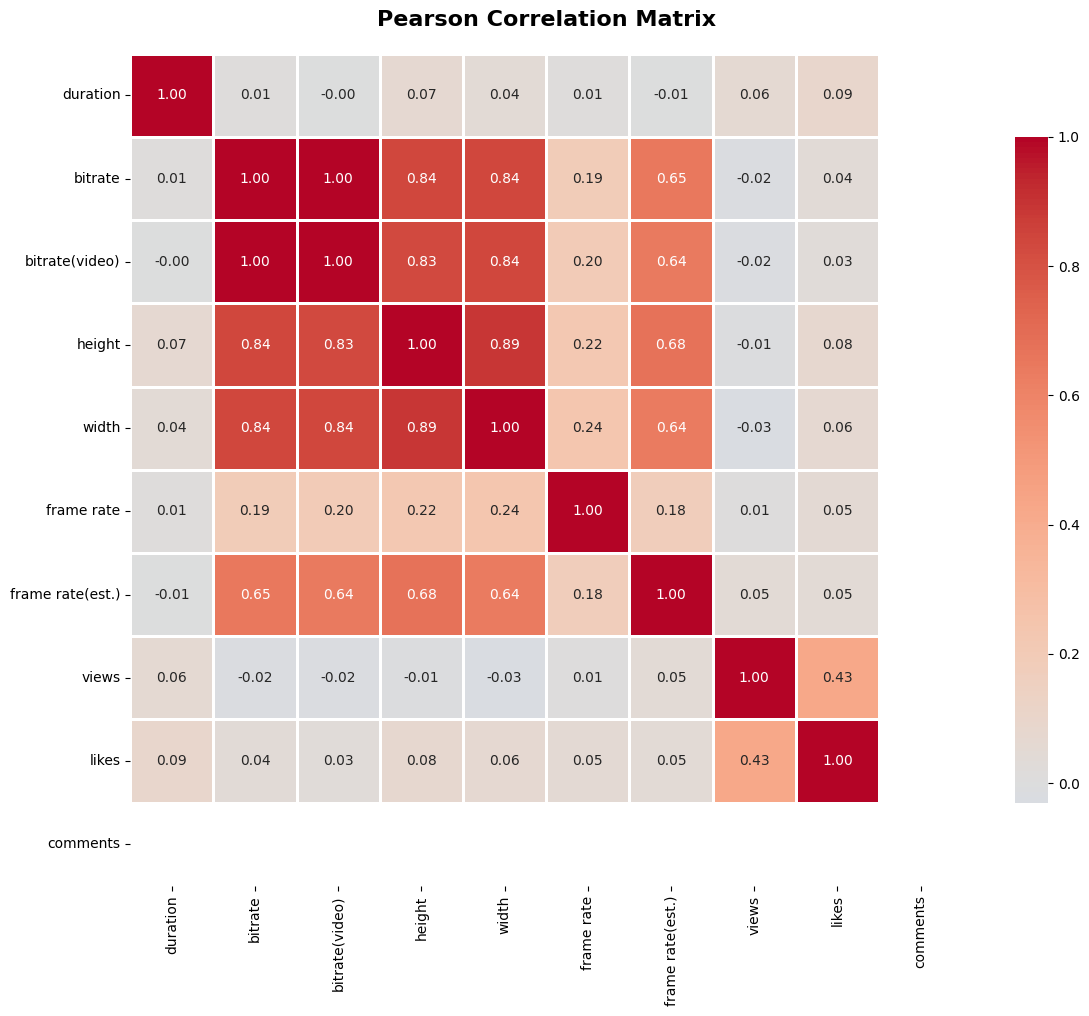

In [7]:
# Heatmap - Pearson Correlation
plt.figure(figsize=(12, 10))
sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Pearson Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

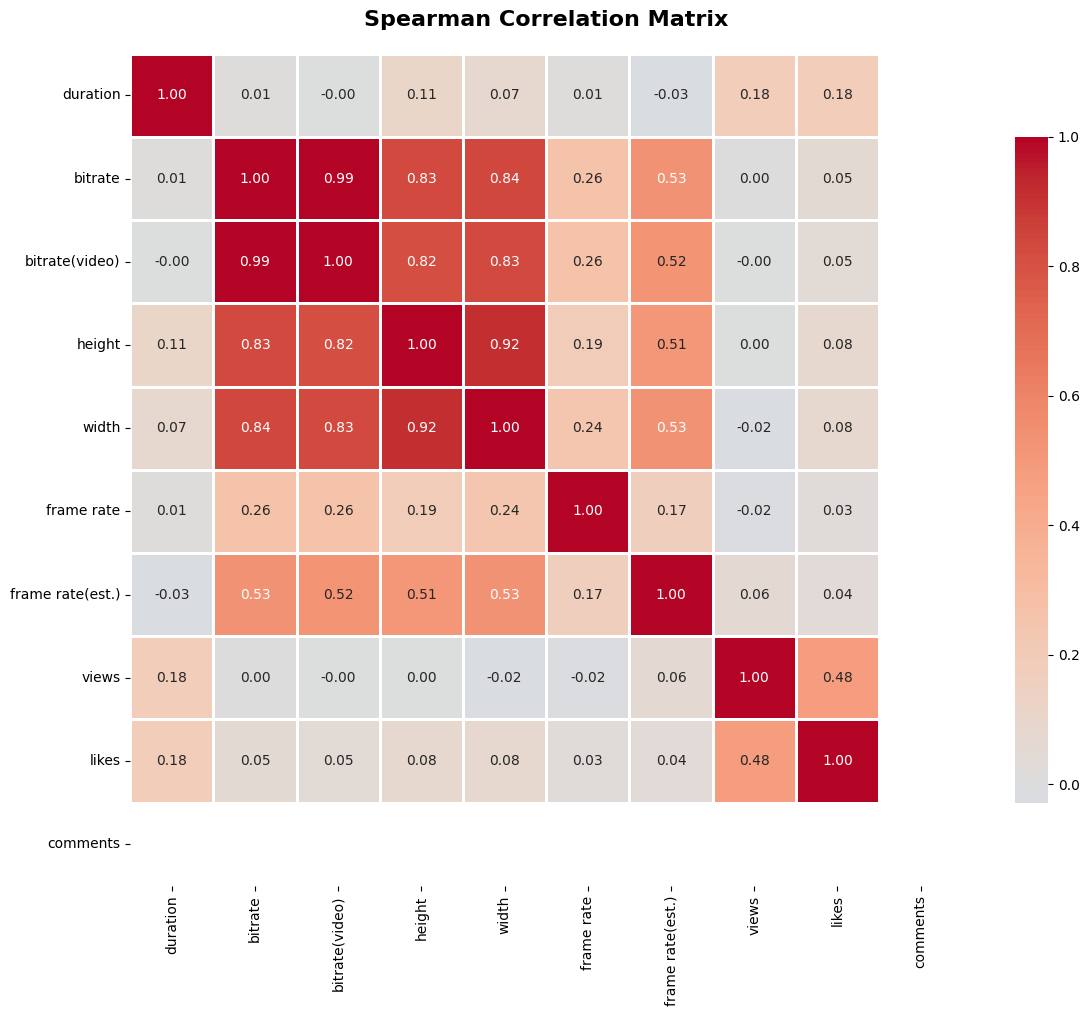

In [8]:
# Heatmap - Spearman Correlation
plt.figure(figsize=(12, 10))
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Spearman Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 3. High Correlation Pairs

Tìm các cặp biến có correlation cao (|r| > 0.7).

In [10]:
# Tìm các cặp biến có correlation cao
def find_high_correlation_pairs(corr_matrix, threshold=0.7):
    high_corr_pairs = []
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                high_corr_pairs.append({
                    'Variable 1': corr_matrix.columns[i],
                    'Variable 2': corr_matrix.columns[j],
                    'Pearson r': round(pearson_corr.iloc[i, j], 3),
                    'Spearman ρ': round(spearman_corr.iloc[i, j], 3),
                    'Strength': 'Strong' if abs(corr_matrix.iloc[i, j]) > 0.8 else 'Moderate'
                })
    
    return pd.DataFrame(high_corr_pairs).sort_values('Pearson r', ascending=False, key=abs)

# Tìm high correlation pairs (Pearson)
high_corr_df = find_high_correlation_pairs(pearson_corr, threshold=0.7)
high_corr_df

,Variable 1,Variable 2,Pearson r,Spearman ρ,Strength
0,bitrate,bitrate(video),0.996,0.992,Strong
5,height,width,0.889,0.915,Strong
2,bitrate,width,0.842,0.838,Strong
1,bitrate,height,0.841,0.829,Strong
4,bitrate(video),width,0.836,0.829,Strong
3,bitrate(video),height,0.834,0.817,Strong


## 4. Scatter Plots for High Correlation Pairs

Visualize các cặp biến có correlation cao.

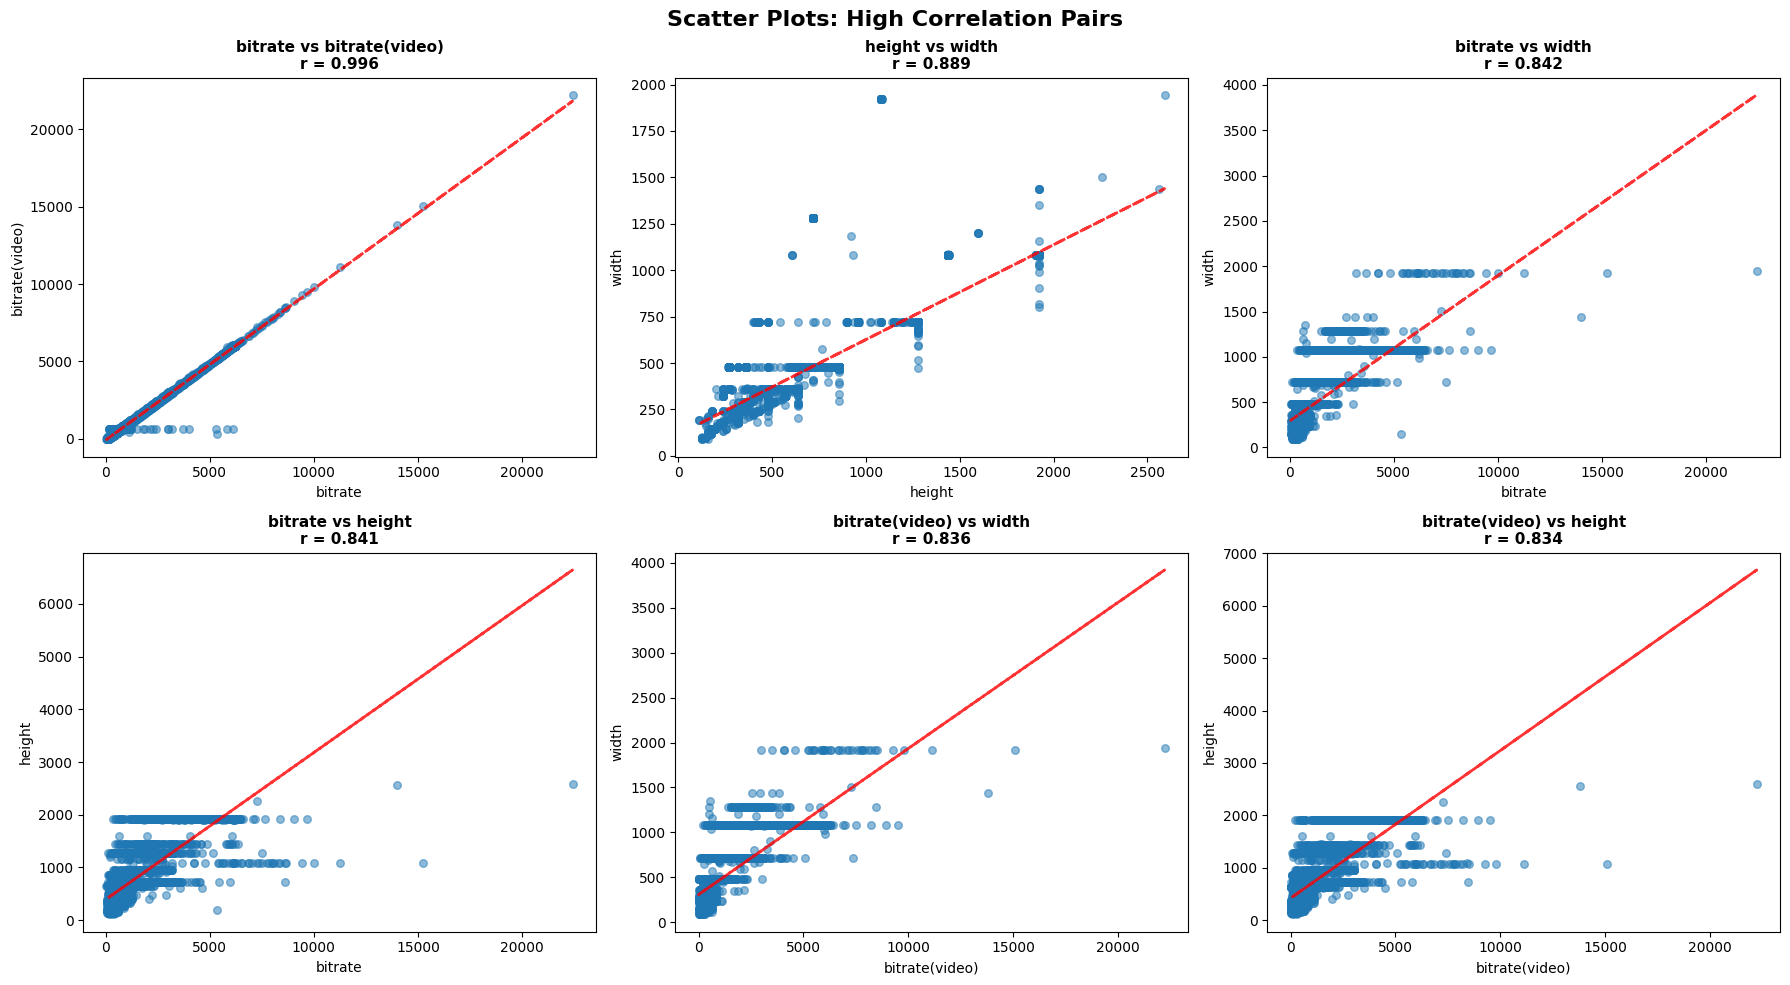

In [12]:
# Scatter plots cho các cặp có correlation cao
if len(high_corr_df) > 0:
    n_pairs = min(6, len(high_corr_df))  # Tối đa 6 plots
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Scatter Plots: High Correlation Pairs', fontsize=16, fontweight='bold')
    
    axes = axes.flatten()
    
    for idx in range(n_pairs):
        var1 = high_corr_df.iloc[idx]['Variable 1']
        var2 = high_corr_df.iloc[idx]['Variable 2']
        r = high_corr_df.iloc[idx]['Pearson r']
        
        ax = axes[idx]
        ax.scatter(df[var1], df[var2], alpha=0.5, s=30)
        ax.set_xlabel(var1, fontsize=10)
        ax.set_ylabel(var2, fontsize=10)
        ax.set_title(f'{var1} vs {var2}\nr = {r:.3f}', fontsize=11, fontweight='bold')
        
        # Add regression line
        z = np.polyfit(df[var1], df[var2], 1)
        p = np.poly1d(z)
        ax.plot(df[var1], p(df[var1]), "r--", alpha=0.8, linewidth=2)
    
    # Hide unused subplots
    for idx in range(n_pairs, 6):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

## 5. Engagement Variables Correlation

Phân tích riêng mối tương quan giữa các biến engagement (views, likes, comments).

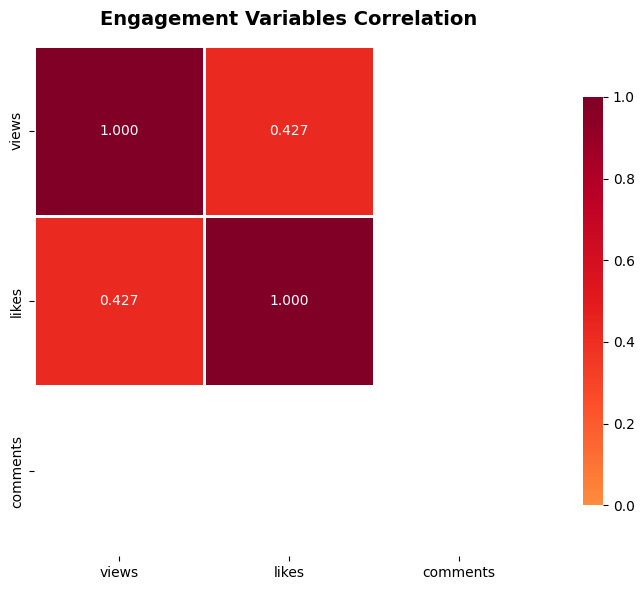

          views  likes  comments
views     1.000  0.427       NaN
likes     0.427  1.000       NaN
comments    NaN    NaN       NaN


In [13]:
engagement_cols = ['views', 'likes', 'comments']
engagement_corr = df[engagement_cols].corr(method='pearson')

# Heatmap cho engagement variables
plt.figure(figsize=(8, 6))
sns.heatmap(engagement_corr, annot=True, fmt='.3f', cmap='YlOrRd', 
            center=0, square=True, linewidths=2, cbar_kws={"shrink": 0.8},
            vmin=0, vmax=1)
plt.title('Engagement Variables Correlation', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print(engagement_corr.round(3))

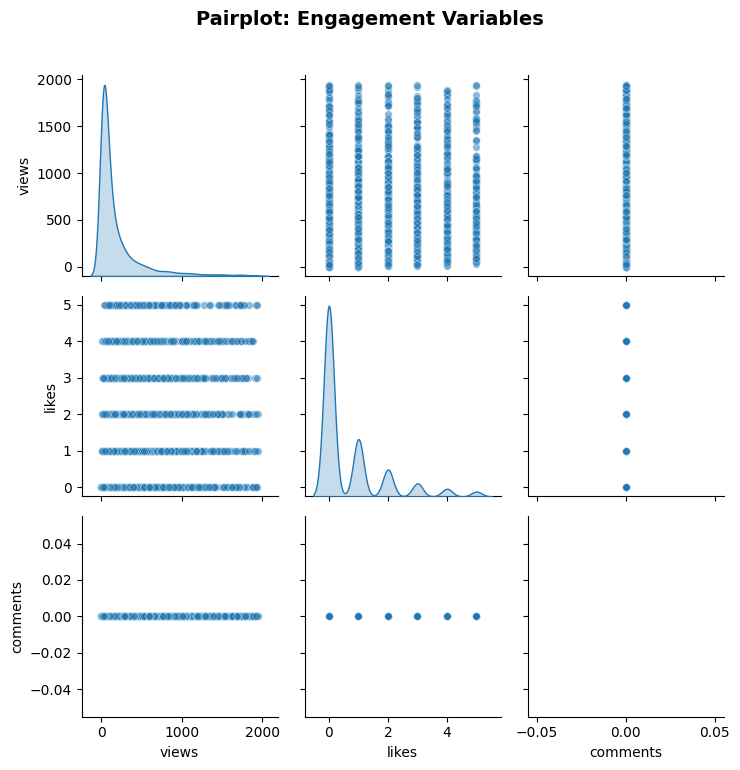

In [14]:
# Pairplot cho engagement variables
sns.pairplot(df[engagement_cols], diag_kind='kde', plot_kws={'alpha': 0.5, 's': 30})
plt.suptitle('Pairplot: Engagement Variables', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### High Correlation Pairs (|r| > 0.7)
- **bitrate và bitrate(video)**: r xấp xỉ 0.9 trở lên - Hai biến gần như đo cùng 1 thông số
- **height và width**: r xấp xỉ 0.8 trở lên - Tỷ lệ khung hình (aspect ratio) tương đối cố định
- **frame rate và frame rate(est.)**: r xấp xỉ 0.9 trở lên - Giá trị ước tính rất gần với giá trị thực

### Engagement Variables Correlation
- **views và likes**: Correlation trung bình đến cao - Videos có nhiều views thường nhận nhiều likes
- **views và comments**: Correlation trung bình - Views cao không tỷ lệ thuận với comments
- **likes và comments**: Correlation cao - Người dùng thích và comment thường đi kèm nhau

### Technical vs Engagement
- Correlation yếu giữa technical specs (bitrate, resolution, frame rate) và engagement metrics (views, likes, comments)
- Chất lượng kỹ thuật video không có mối quan hệ tuyến tính mạnh với tương tác người dùng

### Multicollinearity Detection
Phát hiện multicollinearity ở:
- Cặp bitrate variables
- Cặp frame rate variables
- Một số engagement variables có correlation cao với nhau